# Recreating the figures from Flournoy et al. (2021)

https://journals.ametsoc.org/view/journals/wefo/36/3/WAF-D-20-0192.1.xml

In [1]:
from case_functions import *
from compositing_functions import *


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
dates = ['20220523', '20220524','20220611','20230524', '20230527', '20230601', '20230609',
        '20230611', '20230612', '20230613','20230615', '20240427', '20240501', '20240506', '20240519'
          '20240523', '20240602'] #'20240528',
kas = ['ka1', 'ka2']
heights = np.arange(50, 2010, 10)
weights = [0.05, 0.2, 0.5, 0.2, 0.05]

In [3]:
very_dark_red = "#4B0000"

In [4]:
df_all_new = pd.DataFrame()
#for ka in kas:
for d in dates:
    for file in glob.glob(f'case_dfs/new/new_secondtrip/*/{d}_uv_*_all.csv'):
        try:
            not_comp_file_name_new = file
            print(not_comp_file_name_new)
            df_new = pd.read_csv(not_comp_file_name_new)
            df_new['Date'] = d
            print(np.shape(df_new))
            if df_new['Time From Tor (min)'].eq('nontor').any():
                df_new['Tor or Nontor'] = 'nontor'
            else:
                df_new['Tor or Nontor'] = 'tor'
                
            df_all_new = pd.concat([df_all_new, df_new], ignore_index=True)
        except FileNotFoundError:
            print(f"File not found: {not_comp_file_name_new}")
            continue

case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka1_all.csv
(120, 202)
case_dfs/new/new_secondtrip/tornadic/20220523_uv_ka2_all.csv
(20, 202)
case_dfs/new/new_secondtrip/nontornadic/20220524_uv_ka1_all.csv
(100, 202)
case_dfs/new/new_secondtrip/tornadic/20230524_uv_ka2_all.csv
(284, 202)
case_dfs/new/new_secondtrip/tornadic/20230527_uv_ka1_all.csv
(506, 202)
case_dfs/new/new_secondtrip/nontornadic/20230611_uv_ka1_all.csv
(388, 202)
case_dfs/new/new_secondtrip/nontornadic/20230612_uv_ka2_all.csv
(198, 202)
case_dfs/new/new_secondtrip/nontornadic/20230613_uv_ka1_all.csv
(20, 202)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka1_all.csv
(572, 202)
case_dfs/new/new_secondtrip/tornadic/20230615_uv_ka2_all.csv
(352, 202)
case_dfs/new/new_secondtrip/nontornadic/20240427_uv_ka1_all.csv
(314, 202)
case_dfs/new/new_secondtrip/nontornadic/20240501_uv_ka1_all.csv
(850, 202)
case_dfs/new/new_secondtrip/tornadic/20240602_uv_ka1_all.csv
(262, 202)


In [5]:
# Get the list of column names greater than 100
#cols_above_100 = [str(i) for i in range(101, 199)]  # up to 198
cols_above_100 = [col for col in df_all_new.columns if col.isdigit() and 100 <= int(col) <= 198]
# Set those columns to NaN for the target date
df_all_new.loc[df_all_new['Date'] == '20240501', cols_above_100] = np.nan
#df_all_new.loc[df_all_new['Date'] == '20240528', cols_above_100] = np.nan

In [6]:
def time_from_tor(ka_df, storm_event_data, event_type, tornado_location, timezone, daylight_savings):
    '''
    This function uses .csv from NOAA's Storm Events Database to compare 
    the times VADs were taken with when the tornado was reported.

    ka_df = dataframe you want the tor ids to be added to
    date = date the data from the storm event database was recorded (MMDDYYYY)
    event_type = is typically 'Tornado' but for posterity left it as a variable
    storm_event_data = csv from the storm event database
    tornado_location = str of the desired location name IN ALL CAPS
    timezone = str of timezone in format US/timezone (Central, Mountain, etc)
    daylight_savings = False, the database reports in standard time, even during daylight savings
    '''
    tor_begin_time = []
    tor_end_time = []
    tor_begin_date = []
    tor_end_date = []
    vads_tor_time = []
    vads_tor_nontor = []
    tor_id = storm_event_data.EVENT_TYPE == event_type
    tor_loc = storm_event_data.BEGIN_LOCATION.isin(tornado_location)
    
    for i in range(len(tor_id)):
        if tor_id[i] == True and tor_loc[i] == True:
            print(storm_event_data.BEGIN_TIME[i], storm_event_data.BEGIN_LOCATION[i])
            tor_begin_time.append(storm_event_data.BEGIN_TIME[i])
            tor_end_time.append(storm_event_data.END_TIME[i])
            tor_begin_date.append(storm_event_data.BEGIN_DATE[i])
            tor_end_date.append(storm_event_data.END_DATE[i])
        else:
            continue
            
    tor_begin_time_array = np.array(tor_begin_time)
    tor_end_time_array = np.array(tor_end_time)

    tor_start_dt_list = []
    tor_end_dt_list = []
    
    for i in range(len(tor_begin_time_array)):
        tor_start = tor_begin_date[i] + str(f' {tor_begin_time_array[i]}')
        tor_start_dt = datetime.strptime(tor_start, '%m/%d/%Y %H%M')
        print(tor_start_dt)
        local_time_start = pytz.timezone(timezone).localize(tor_start_dt, is_dst = daylight_savings)
        
        if local_time_start.dst() != timedelta(0):  # DST is in effect
            # Manually adjust by adding one hour
            corrected_time_start = local_time_start + timedelta(hours=1)
        else:
            # No DST adjustment needed
            corrected_time_start = local_time_start

        start_utc = corrected_time_start.astimezone(pytz.utc)
        tor_start_dt_list.append(start_utc)
        
        tor_end = tor_end_date[i] + str(f' {tor_end_time_array[i]}')
        tor_end_dt = datetime.strptime(tor_end, '%m/%d/%Y %H%M')
        local_time_end = pytz.timezone(timezone).localize(tor_end_dt, is_dst = daylight_savings)

        if local_time_end.dst() != timedelta(0):  # DST is in effect
            # Manually adjust by adding one hour
            corrected_time_end = local_time_end + timedelta(hours=1)
        else:
            # No DST adjustment needed
            corrected_time_end = local_time_end

        end_utc = corrected_time_end.astimezone(pytz.utc)
        tor_end_dt_list.append(end_utc)

    print(f'start:{min(tor_start_dt_list)}')
    print(f'end:{max(tor_end_dt_list)}')
    
    for dt_str in ka_df.Datetime:
        dt_str = str(dt_str)
        dt = datetime.strptime(dt_str + str(f'+00:00'), '%Y-%m-%d %H:%M:%S%z') # makes non naive datetime
        #to_tor = (tor_start_dt_list[0] - dt).total_seconds() / 60 time after tor is negative
        #to_tor = (dt - tor_start_dt_list[0]).total_seconds() / 60 # time after tor is positive
        
        # if (tor_start_dt_list[0] <= dt <= max(tor_end_dt_list)): # if time occurs while tornado is ongoing, time til tor =0
        #     vads_tor_time.append(0)
        # else:
        #     to_tor = (dt - tor_start_dt_list[0]).total_seconds() / 60
        #     vads_tor_time.append(to_tor)

        if (min(tor_start_dt_list) <= dt <= max(tor_end_dt_list)): # if time occurs while tornado is ongoing, time til tor =0
            vads_tor_time.append(0)
        else:
            to_tor = (dt - min(tor_start_dt_list)).total_seconds() / 60
            vads_tor_time.append(to_tor)

    return vads_tor_time

In [7]:
vad_df = df_all_new[df_all_new['Date'] == '20220523']
morton = pd.read_csv('/Users/juliabman/Desktop/storm_events_data/storm_data_search_results_20220523.csv')
tor_df, tor_nontor = tor_id_new_time(vad_df, morton, str('Tornado'), ['MORTON', 'MORTON COCHRAN CO AR', 'ENOCHS', 'PETTIT', 'PEP', 'COBLE'], str('US/Central'), False)
times = time_from_tor_fixed_tor_time(vad_df, morton, str('Tornado'), ['MORTON', 'MORTON COCHRAN CO AR', 'ENOCHS', 'PETTIT', 'PEP', 'COBLE'], str('US/Central'), False)
#vad_df['Tor Times'] = tor_df
#vad_df['Tor or Nontor'] = tor_nontor
vad_df['Time From Tor (min)'] = times
df_all_new.loc[df_all_new['Date'] == '20220523', 'Time From Tor (min)'] = times

1750 MORTON
1803 MORTON
1812 ENOCHS
1813 MORTON COCHRAN CO AR
1817 ENOCHS
1840 MORTON COCHRAN CO AR
1906 PEP
1914 MORTON COCHRAN CO AR
1928 PETTIT
1937 PETTIT
1940 COBLE
2022-05-23 17:50:00
2022-05-23 18:03:00
2022-05-23 18:12:00
2022-05-23 18:13:00
2022-05-23 18:17:00
2022-05-23 18:40:00
2022-05-23 19:06:00
2022-05-23 19:14:00
2022-05-23 19:28:00
2022-05-23 19:37:00
2022-05-23 19:40:00
2022-05-23 23:50:00+00:00
1750 MORTON
1803 MORTON
1812 ENOCHS
1813 MORTON COCHRAN CO AR
1817 ENOCHS
1840 MORTON COCHRAN CO AR
1906 PEP
1914 MORTON COCHRAN CO AR
1928 PETTIT
1937 PETTIT
1940 COBLE
2022-05-23 17:50:00
2022-05-23 18:03:00
2022-05-23 18:12:00
2022-05-23 18:13:00
2022-05-23 18:17:00
2022-05-23 18:40:00
2022-05-23 19:06:00
2022-05-23 19:14:00
2022-05-23 19:28:00
2022-05-23 19:37:00
2022-05-23 19:40:00
start:2022-05-23 23:50:00+00:00
end:2022-05-24 01:58:00+00:00


In [8]:
d = '20230615'
vad_df = df_all_new[df_all_new['Date'] == d]
tor_data = pd.read_csv(f'/Users/juliabman/Desktop/storm_events_data/storm_data_search_results_{d}.csv')
tor_df, tor_nontor = tor_id_new_time(vad_df, tor_data, str('Tornado'), list(np.array(tor_data.BEGIN_LOCATION)), str('US/Central'), False)
times = time_from_tor(vad_df, tor_data, str('Tornado'), list(np.array(tor_data.BEGIN_LOCATION)), str('US/Central'), False)
#vad_df['Tor Times'] = tor_df
#vad_df['Tor or Nontor'] = tor_nontor
vad_df['Time From Tor (min)'] = times

df_all_new.loc[df_all_new['Date'] == d, 'Time From Tor (min)'] = times

1558 FAXON
1610 WALTERS ARPT
1611 EMPIRE CITY
1634 SUNRAY
1637 COMANCHE
1658 SUGDEN
1703 LOCO
1716 LOCO
1721 RINGLING
1731 ARNETT
1747 DURHAM
1826 MARIETTA
2023-06-15 15:58:00
2023-06-15 16:10:00
2023-06-15 16:11:00
2023-06-15 16:34:00
2023-06-15 16:37:00
2023-06-15 16:58:00
2023-06-15 17:03:00
2023-06-15 17:16:00
2023-06-15 17:21:00
2023-06-15 17:31:00
2023-06-15 17:47:00
2023-06-15 18:26:00
2023-06-15 21:58:00+00:00
1558 FAXON
1610 WALTERS ARPT
1611 EMPIRE CITY
1634 SUNRAY
1637 COMANCHE
1658 SUGDEN
1703 LOCO
1716 LOCO
1721 RINGLING
1731 ARNETT
1747 DURHAM
1826 MARIETTA
2023-06-15 15:58:00
2023-06-15 16:10:00
2023-06-15 16:11:00
2023-06-15 16:34:00
2023-06-15 16:37:00
2023-06-15 16:58:00
2023-06-15 17:03:00
2023-06-15 17:16:00
2023-06-15 17:21:00
2023-06-15 17:31:00
2023-06-15 17:47:00
2023-06-15 18:26:00
start:2023-06-15 21:58:00+00:00
end:2023-06-16 00:27:00+00:00


In [9]:
rt_times_manual = pd.read_csv('/Users/juliabman/Downloads/rt_times.csv', dtype={'Date':str})

In [10]:
rt_times_manual

,Date,t_CI,t_rt
0,20220523,23:04:00,23:42:00
1,20220524,19:24:00,21:56:00
2,20220611,21:08:00,22:10:00
3,20230524,22:20:00,23:00:00
4,20230527,21:36:00,0:26:00
5,20230601,20:00:00,21:26:00
6,20230611,18:30:00,20:26:00
7,20230613,19:00:00,19:30:00
8,20230615,21:02:00,23:45:00
9,20240427,17:56:00,19:30:00


In [43]:
df_all_new.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '193', '194', '195', 'u or v', 'Distance', 'Angle',
       'Time From Tor (min)', 'Datetime', 'Date', 'Tor or Nontor'],
      dtype='object', length=203)

In [60]:
tor_time = df_all_new.loc[
    df_all_new['Time From Tor (min)'] == 0,
    'Datetime'
]

tor_date = df_all_new.loc[
    df_all_new['Time From Tor (min)'] == 0,
    'Date'
]

In [61]:
tor_date_time = pd.concat([tor_time, tor_date], axis=1)
tor_date_time

,Datetime,Date
55,2022-05-23 23:50:43,20220523
56,2022-05-23 23:51:12,20220523
57,2022-05-23 23:51:43,20220523
58,2022-05-23 23:59:39,20220523
59,2022-05-24 00:02:09,20220523
...,...,...
3939,2024-06-03 01:18:49,20240602
3940,2024-06-03 01:19:03,20240602
3941,2024-06-03 01:19:17,20240602
3942,2024-06-03 01:19:30,20240602


In [62]:
tor_nontor_date

55      20220523
56      20220523
57      20220523
58      20220523
59      20220523
          ...   
3719    20240501
3720    20240501
3721    20240501
3722    20240501
3723    20240501
Name: Date, Length: 2678, dtype: object

In [63]:
first_tor_time_df = (
    tor_date_time.groupby('Date')
    .first()
    #.add_prefix('First ')
    .reset_index()
)

In [71]:
first_tor_time_df['Datetime DT'] = pd.to_datetime(first_tor_time_df["Datetime"])

In [72]:
first_tor_time_df

,Date,Datetime,Datetime DT
0,20220523,2022-05-23 23:50:43,2022-05-23 23:50:43
1,20230527,2023-05-28 01:26:00,2023-05-28 01:26:00
2,20230615,2023-06-15 22:58:33,2023-06-15 22:58:33
3,20240602,2024-06-03 01:09:01,2024-06-03 01:09:01


In [65]:
# Combine Date + time columns into real datetimes
rt_times_manual["dt_CI"] = pd.to_datetime(rt_times_manual["Date"] + " " + rt_times_manual["t_CI"], format="%Y%m%d %H:%M:%S")
rt_times_manual["dt_rt"] = pd.to_datetime(rt_times_manual["Date"] + " " + rt_times_manual["t_rt"], format="%Y%m%d %H:%M:%S")

# If t_rt is earlier than t_CI, it must have rolled past midnight -> add a day
rt_times_manual.loc[rt_times_manual["dt_rt"] < rt_times_manual["dt_CI"], "dt_rt"] += pd.Timedelta(days=1)

rt_times_manual["dt (min)"] = (rt_times_manual["dt_rt"] - rt_times_manual["dt_CI"]).dt.total_seconds() / 60

In [66]:
rt_times_manual

,Date,t_CI,t_rt,dt_CI,dt_rt,dt (min)
0,20220523,23:04:00,23:42:00,2022-05-23 23:04:00,2022-05-23 23:42:00,38.0
1,20220524,19:24:00,21:56:00,2022-05-24 19:24:00,2022-05-24 21:56:00,152.0
2,20220611,21:08:00,22:10:00,2022-06-11 21:08:00,2022-06-11 22:10:00,62.0
3,20230524,22:20:00,23:00:00,2023-05-24 22:20:00,2023-05-24 23:00:00,40.0
4,20230527,21:36:00,0:26:00,2023-05-27 21:36:00,2023-05-28 00:26:00,170.0
5,20230601,20:00:00,21:26:00,2023-06-01 20:00:00,2023-06-01 21:26:00,86.0
6,20230611,18:30:00,20:26:00,2023-06-11 18:30:00,2023-06-11 20:26:00,116.0
7,20230613,19:00:00,19:30:00,2023-06-13 19:00:00,2023-06-13 19:30:00,30.0
8,20230615,21:02:00,23:45:00,2023-06-15 21:02:00,2023-06-15 23:45:00,163.0
9,20240427,17:56:00,19:30:00,2024-04-27 17:56:00,2024-04-27 19:30:00,94.0


In [13]:
df_copy = df_all_new.copy()
df_copy['Datetime Int'] = pd.to_datetime(df_all_new['Datetime'])

In [14]:
df_copy['NF or FF'] = np.where(df_copy['Distance'] <= 30, 'nf', 'ff')

In [15]:
def right_turn_time(date, date_utc):
    
    test_case4 = df_copy[(df_copy['Date'] == date)]
    #rt_time = pd.Timestamp(date_utc)
    
    test_case4['Right Turn'] = np.where(test_case4['Datetime Int'] < date_utc,
                                       'before',
                                       'after'
                                      )
    return test_case4

In [16]:
def normalize_rt_time(test_case2, rt_time):
    test_case2['dt_rt'] = test_case2['Datetime Int'] - rt_time
    test_case2['dt_rt (min)'] = ((test_case2['Datetime Int'] - rt_time).dt.total_seconds() / 60).astype(float)

In [17]:
def rt_time_groups(test_case2, x):
    
    group1 = np.nanmean(test_case2[(test_case2['dt_rt (min)'] > -61) & (test_case2['dt_rt (min)'] < -44)][x], axis=0)
    group2 = np.nanmean(test_case2[(test_case2['dt_rt (min)'] > -46) & (test_case2['dt_rt (min)'] < -29)][x], axis=0)
    group3 = np.nanmean(test_case2[(test_case2['dt_rt (min)'] > -31) & (test_case2['dt_rt (min)'] < -14)][x], axis=0)
    group4 = np.nanmean(test_case2[(test_case2['dt_rt (min)'] > -16) & (test_case2['dt_rt (min)'] < 1)][x], axis=0)

    return group1, group2, group3, group4

In [18]:
def composite_srh_nan(u,v):
    '''
    Computes storm-relative helicity at every height then takes the sum for total SRH
    u,v = composite u,v values for desired location up to desired height
    u and v MUST BE STORM RELATIVE, this function does not account for storm motion in equations
    '''
    srh = []
    for i in range(len(u)-1):
        a = np.nanprod([u[i+1], v[i]], axis=0)
        b = -np.nanprod([u[i], v[i+1]], axis=0)
        
        srh0 = np.nansum([a, b], axis=0)
        srh.append(srh0)
        
    srh_array = np.array(srh)
    srh_total = np.nansum(srh_array) # total srh
        
    return srh_total

In [19]:
def calc_srh_for_heights(test_case2):
    
    srh_2km = [composite_srh_nan(test_case2[test_case2['u or v'] == 'u'].iloc[i,:196], test_case2[test_case2['u or v'] == 'v'].iloc[i,:196])
            for i in range(len(test_case2[test_case2['u or v'] == 'u']))]

    srh_1km = [composite_srh_nan(test_case2[test_case2['u or v'] == 'u'].iloc[i,:100], test_case2[test_case2['u or v'] == 'v'].iloc[i,:100])
                for i in range(len(test_case2[test_case2['u or v'] == 'u']))]
    
    srh_500m = [composite_srh_nan(test_case2[test_case2['u or v'] == 'u'].iloc[i,:50], test_case2[test_case2['u or v'] == 'v'].iloc[i,:50])
                for i in range(len(test_case2[test_case2['u or v'] == 'u']))]

    srh_250m = [composite_srh_nan(test_case2[test_case2['u or v'] == 'u'].iloc[i,:25], test_case2[test_case2['u or v'] == 'v'].iloc[i,:25])
                for i in range(len(test_case2[test_case2['u or v'] == 'u']))]

    srh_100m = [composite_srh_nan(test_case2[test_case2['u or v'] == 'u'].iloc[i,:10], test_case2[test_case2['u or v'] == 'v'].iloc[i,:10])
                for i in range(len(test_case2[test_case2['u or v'] == 'u']))]

    return srh_2km, srh_1km, srh_500m, srh_250m, srh_100m

In [20]:
def calc_srw_for_heights(test_case2):

    u = test_case2[test_case2['u or v'] == 'u']
    v = test_case2[test_case2['u or v'] == 'v']
    
    srh_2km = comp_srw(u,v, 194)

    srh_1km = comp_srw(u,v, 100)
    
    srh_500m = comp_srw(u,v, 50)

    srh_250m = comp_srw(u,v, 25)

    srh_100m = comp_srw(u,v, 10)

    return srh_2km, srh_1km, srh_500m, srh_250m, srh_100m

In [21]:
def name_columns(test_case2, variable, srh_2km, srh_1km, srh_500m, srh_250m, srh_100m):
    
    test_case2.loc[test_case2[test_case2['u or v'] == 'u'].index, f'{variable}02km'] = srh_2km
    test_case2.loc[test_case2[test_case2['u or v'] == 'v'].index, f'{variable}02km'] = srh_2km
    
    test_case2.loc[test_case2[test_case2['u or v'] == 'u'].index, f'{variable}01km'] = srh_1km
    test_case2.loc[test_case2[test_case2['u or v'] == 'v'].index, f'{variable}01km'] = srh_1km
    
    test_case2.loc[test_case2[test_case2['u or v'] == 'u'].index, f'{variable}0500m'] = srh_500m
    test_case2.loc[test_case2[test_case2['u or v'] == 'v'].index, f'{variable}0500m'] = srh_500m

    test_case2.loc[test_case2[test_case2['u or v'] == 'u'].index, f'{variable}0250m'] = srh_250m
    test_case2.loc[test_case2[test_case2['u or v'] == 'v'].index, f'{variable}0250m'] = srh_250m
    
    test_case2.loc[test_case2[test_case2['u or v'] == 'u'].index, f'{variable}0100m'] = srh_100m
    test_case2.loc[test_case2[test_case2['u or v'] == 'v'].index, f'{variable}0100m'] = srh_100m

In [22]:
cases_df = pd.DataFrame()

for i in rt_times_manual['Date'].unique():
    print(i)
    rt_time = rt_times_manual[rt_times_manual['Date'] == i].iloc[0]['dt_rt'] # get time
    print(rt_time)

    test_case = right_turn_time(i, rt_time)
    srh_2km, srh_1km, srh_500m, srh_250m, srh_100m = calc_srh_for_heights(test_case)
    srw_2km, srw_1km, srw_500m, srw_250m, srw_100m = calc_srw_for_heights(test_case)
    name_columns(test_case, 'SRH', srh_2km, srh_1km, srh_500m, srh_250m, srh_100m)
    name_columns(test_case, 'SRW', srw_2km, srw_1km, srw_500m, srw_250m, srw_100m)
    normalize_rt_time(test_case, rt_time)
    g1, g2, g3, g4 = rt_time_groups(test_case, 'SRH01km')

    cases_df = pd.concat([cases_df, test_case], ignore_index=True)

20220523
2022-05-23 23:42:00
20220524
2022-05-24 21:56:00
20220611
2022-06-11 22:10:00
20230524
2023-05-24 23:00:00
20230527
2023-05-28 00:26:00
20230601
2023-06-01 21:26:00
20230611
2023-06-11 20:26:00
20230613
2023-06-13 19:30:00
20230615
2023-06-15 23:45:00
20240427
2024-04-27 19:30:00
20240501
2024-05-01 23:24:00
20240502
2024-05-03 01:30:00
20240504
2024-05-04 23:00:00
20240519
2024-05-19 22:00:00
20240523
2024-05-23 22:50:00
20240602
2024-06-03 00:30:00


In [78]:
first_tor_time_df["Datetime DT"]

0   2022-05-23 23:50:43
1   2023-05-28 01:26:00
2   2023-06-15 22:58:33
3   2024-06-03 01:09:01
Name: Datetime DT, dtype: datetime64[ns]

In [137]:
# cases_df["rt - torgen (min)"] = np.nan
# cases_df["ci - torgen (min)"] = np.nan

for d in first_tor_time_df['Date'].unique():

    d_sel = rt_times_manual[rt_times_manual['Date'] == d]
    d_tor = first_tor_time_df[first_tor_time_df['Date'] == d]

    rt_time = d_sel["dt_rt"].iloc[0]
    ci_time = d_sel["dt_CI"].iloc[0]
    tor_time = d_tor["Datetime DT"].iloc[0]

    cases_df.loc[cases_df["Date"] == d, "torgen - rt (min)"] = (
       tor_time - rt_time
    ).total_seconds() / 60

    # + means RT occurred BEFORE tornado, - means RT occurred AFTER

    cases_df.loc[cases_df["Date"] == d, "torgen - ci (min)"] = (
        tor_time - ci_time
    ).total_seconds() / 60

In [138]:
cases_df

,0,1,2,3,4,5,6,7,8,9,...,SRW0500m,SRW0250m,SRW0100m,dt_rt,dt_rt (min),rt - torgen (min),ci - torgen (min),torgen - rt(min),torgen - ci (min),torgen - rt (min)
0,-16.835770,-16.755274,-16.687143,-16.646894,-16.591278,-16.606508,-16.596056,-16.624393,-16.698717,-16.813435,...,19.286532,19.810587,18.694960,-1 days +23:13:10,-46.833333,-8.716667,-46.716667,8.716667,46.716667,8.716667
1,-14.939102,-15.009944,-15.074447,-15.129332,-15.258727,-15.290950,-15.374236,-15.448551,-15.529462,-15.613126,...,18.592601,19.293890,18.291482,-1 days +23:13:40,-46.333333,-8.716667,-46.716667,8.716667,46.716667,8.716667
2,-14.908146,-15.014770,-15.122228,-15.226007,-15.440908,-15.526935,-15.692964,-15.829327,-15.938499,-16.014187,...,18.674639,18.886063,18.238613,-1 days +23:14:10,-45.833333,-8.716667,-46.716667,8.716667,46.716667,8.716667
3,-14.967583,-15.150704,-15.295214,-15.410604,-15.666528,-15.871101,-15.918962,-16.046745,-16.148834,-16.246586,...,18.375407,19.314415,18.661704,-1 days +23:14:39,-45.350000,-8.716667,-46.716667,8.716667,46.716667,8.716667
4,-15.580977,-15.710516,-15.809145,-15.890134,-16.091858,-16.142567,-16.262787,-16.348358,-16.409420,-16.458860,...,18.505256,19.495461,19.552326,-1 days +23:15:09,-44.850000,-8.716667,-46.716667,8.716667,46.716667,8.716667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3783,8.334113,8.148742,7.975159,7.791251,7.791251,7.421818,7.309751,7.078870,6.939043,6.831145,...,18.036254,22.222390,22.254632,0 days 01:44:59,104.983333,-39.016667,-79.016667,39.016667,79.016667,39.016667
3784,10.034555,10.019364,10.019543,10.033887,10.033887,10.057137,10.068593,10.087201,10.106845,10.100788,...,20.327418,22.968426,23.412237,0 days 01:45:25,105.416667,-39.016667,-79.016667,39.016667,79.016667,39.016667
3785,9.410597,9.456664,9.578538,9.788318,9.788318,9.901566,9.884246,9.962052,10.044704,9.977550,...,21.909054,23.381852,22.923105,0 days 01:46:31,106.516667,-39.016667,-79.016667,39.016667,79.016667,39.016667
3786,10.080934,10.150267,10.165607,10.185496,10.185496,10.132746,10.130541,10.069576,10.025705,9.987396,...,20.294975,23.825399,23.780470,0 days 01:46:57,106.950000,-39.016667,-79.016667,39.016667,79.016667,39.016667


In [102]:
cols = ['SRH0100m', 'SRH0250m', 'SRH0500m', 'SRH01km', 'SRH02km']
cols_srw = ['SRW0100m', 'SRW0250m', 'SRW0500m', 'SRW01km', 'SRW02km']

avg_srh_df = cases_df.groupby('Date', as_index=False)[cols].mean()
avg_srw_df = cases_df.groupby('Date', as_index=False)[cols_srw].mean()

# optional: rename to "Avg ..." labels
avg_srh_df = avg_srh_df.rename(columns={c: f'Avg {c}' for c in cols})
avg_srw_df = avg_srw_df.rename(columns={c: f'Avg {c}' for c in cols_srw})

In [103]:
avg_srh_df['t_ci - t_rt'] = rt_times_manual['dt (min)']
avg_srh_df['TNT'] = cases_df.groupby('Date')['Tor or Nontor'].first().values
avg_srh_df['torgen - rt (min)'] = cases_df.groupby('Date')['torgen - rt (min)'].first().values
avg_srh_df['torgen - ci (min)'] = cases_df.groupby('Date')['torgen - ci (min)'].first().values

avg_srw_df['t_ci - t_rt'] = rt_times_manual['dt (min)']
avg_srw_df['TNT'] = cases_df.groupby('Date')['Tor or Nontor'].first().values
avg_srw_df['torgen - rt (min)'] = cases_df.groupby('Date')['torgen - rt (min)'].first().values
avg_srw_df['torgen - ci (min)'] = cases_df.groupby('Date')['torgen - ci (min)'].first().values

In [104]:
avg_srh_df

,Date,Avg SRH0100m,Avg SRH0250m,Avg SRH0500m,Avg SRH01km,Avg SRH02km,t_ci - t_rt,TNT,torgen - rt (min),torgen - ci (min)
0,20220523,8.109902,22.726870,64.482854,132.018582,179.940742,38.0,tor,8.716667,46.716667
1,20220524,0.968450,7.521204,20.541894,53.414833,160.195824,152.0,nontor,NaN,NaN
2,20230524,-2.839331,16.090263,53.913171,168.585174,420.468352,62.0,tor,NaN,NaN
3,20230527,13.013758,42.358086,88.468845,178.039582,214.579911,40.0,tor,60.000000,230.000000
4,20230611,6.049666,24.281898,55.378466,146.703049,230.764692,170.0,nontor,NaN,NaN
5,20230613,3.071447,8.456100,44.278354,129.454287,250.283200,86.0,nontor,NaN,NaN
6,20230615,23.563188,74.620566,128.994032,369.714944,607.931229,116.0,tor,-46.450000,116.550000
7,20240427,18.613305,57.866353,111.049824,198.984654,260.880976,30.0,nontor,NaN,NaN
8,20240501,19.393454,39.968633,64.264519,86.010638,101.081522,163.0,nontor,NaN,NaN
9,20240602,5.610866,20.290107,72.049823,161.857395,198.917177,94.0,tor,39.016667,79.016667


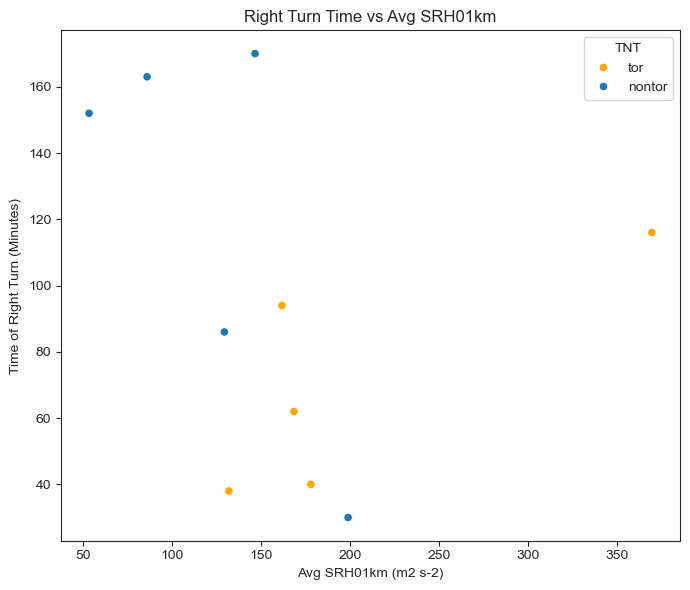

In [26]:
import seaborn as sns
fig = plt.figure(figsize=(7,6))
lab='Avg SRH01km'
sns.scatterplot(data=avg_srh_df, x=lab, y='t_ci - t_rt', hue='TNT', palette=['orange', 'tab:blue'])
plt.ylabel('Time of Right Turn (Minutes)')
plt.xlabel(f'{lab} (m2 s-2)')
plt.title(f'Right Turn Time vs {lab}')
plt.tight_layout()

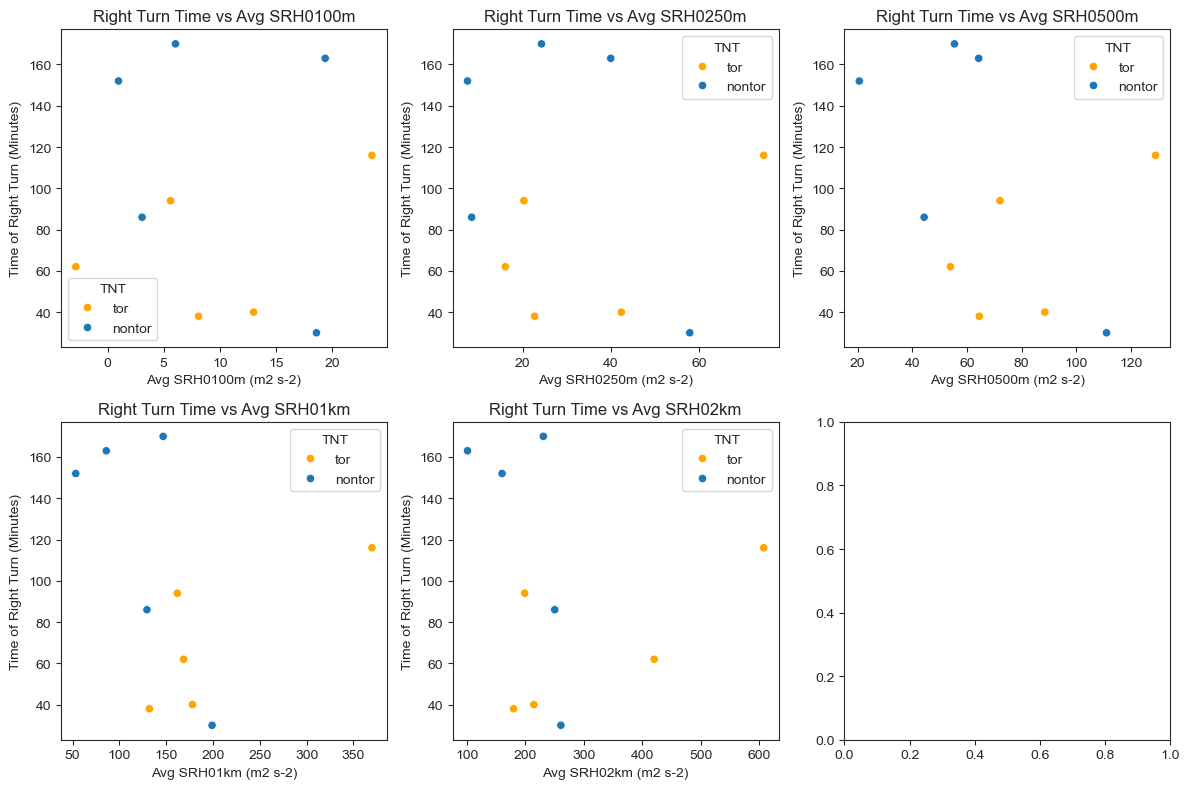

In [140]:
fig, ax = plt.subplots(2,3, figsize=(12,8))
labels = avg_srh_df.filter(regex='^Avg SRH')

for axes, lab in zip(ax.flat, labels):
    sns.scatterplot(data=avg_srh_df, x=lab, y='t_ci - t_rt', hue='TNT', ax=axes, palette=['orange', 'tab:blue'])
    axes.set_ylabel('Time of Right Turn (Minutes)')
    axes.set_xlabel(f'{lab} (m2 s-2)')
    axes.set_title(f'Right Turn Time vs {lab}')
    
    for axes in ax.flat[len(labels):]:
        axes.set_visible(False)

plt.tight_layout()

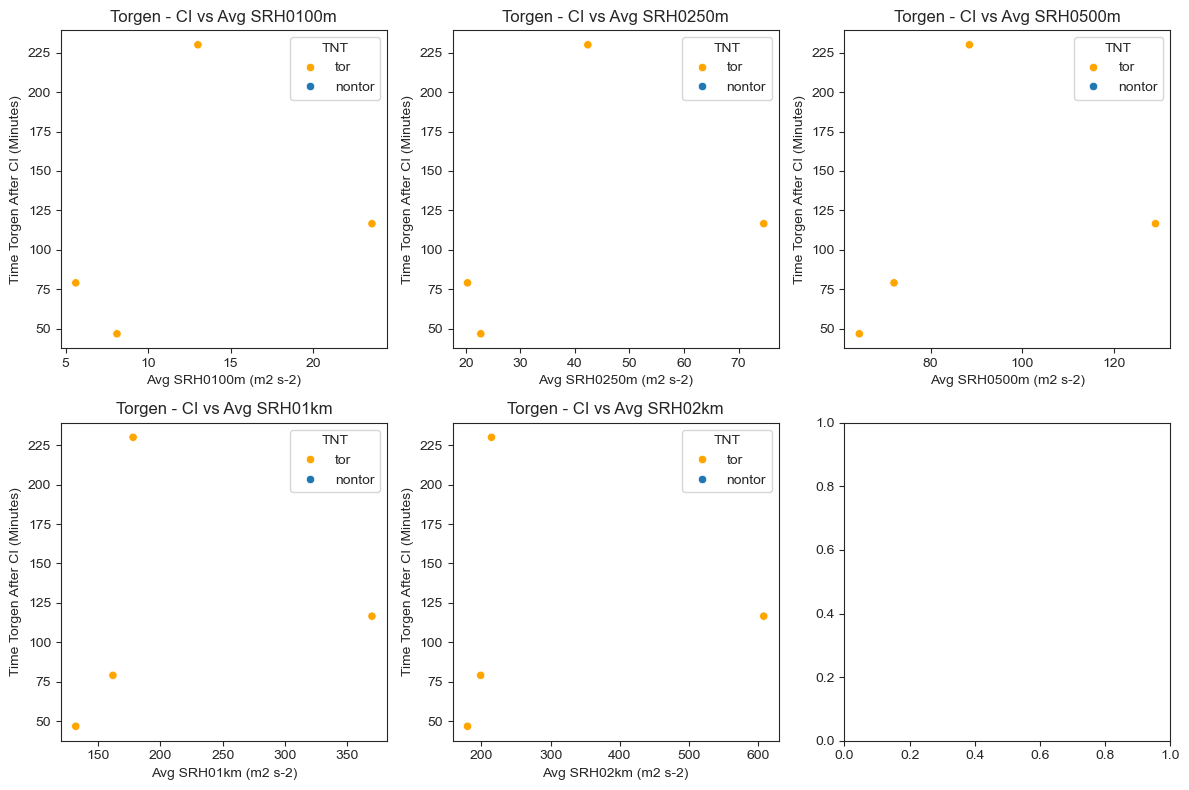

In [139]:
fig, ax = plt.subplots(2,3, figsize=(12,8))
labels = avg_srh_df.filter(regex='^Avg SRH')

for axes, lab in zip(ax.flat, labels):
    sns.scatterplot(data=avg_srh_df, x=lab, y='torgen - ci (min)', hue='TNT', ax=axes, palette=['orange', 'tab:blue'])
    axes.set_ylabel('Time Torgen After CI (Minutes)')
    axes.set_xlabel(f'{lab} (m2 s-2)')
    axes.set_title(f'Torgen - CI vs {lab}')
    
for axes in ax.flat[len(labels):]:
    axes.set_visible(False)

plt.tight_layout()

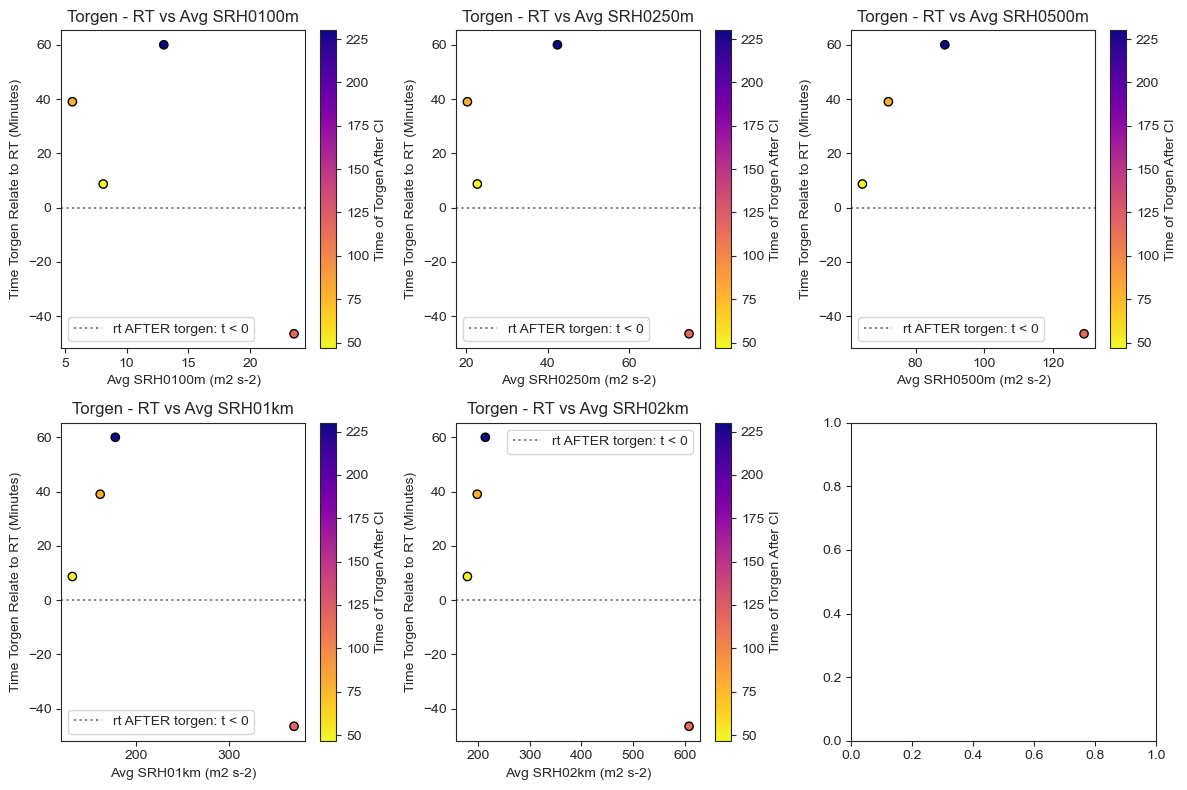

In [151]:
import matplotlib as mpl
fig, ax = plt.subplots(2,3, figsize=(12,8))
labels = avg_srh_df.filter(regex='^Avg SRH')


for axes, lab in zip(ax.flat, labels):
    cmap = plt.cm.plasma_r
    norm = mpl.colors.Normalize(
    vmin=avg_srh_df['torgen - ci (min)'].min(),
    vmax=avg_srh_df['torgen - ci (min)'].max()
        )
    #sns.scatterplot(data=avg_srh_df, x=lab, y='torgen - rt (min)', hue='TNT', ax=axes, palette=['orange', 'tab:blue'])
    scatter = axes.scatter(avg_srh_df[lab], avg_srh_df['torgen - rt (min)'], c= avg_srh_df['torgen - ci (min)'], cmap=cmap, norm=norm, edgecolor='black')
    cbar = fig.colorbar(scatter, ax=axes)
    cbar.set_label('Time of Torgen After CI')
    axes.set_ylabel('Time Torgen Relate to RT (Minutes)')
    axes.set_xlabel(f'{lab} (m2 s-2)')
    axes.set_title(f'Torgen - RT vs {lab}')
    axes.axhline(0, linestyle=':', color='gray', label='rt AFTER torgen: t < 0')
    axes.legend()
    
for axes in ax.flat[len(labels):]:
    axes.set_visible(False)
        
plt.tight_layout()

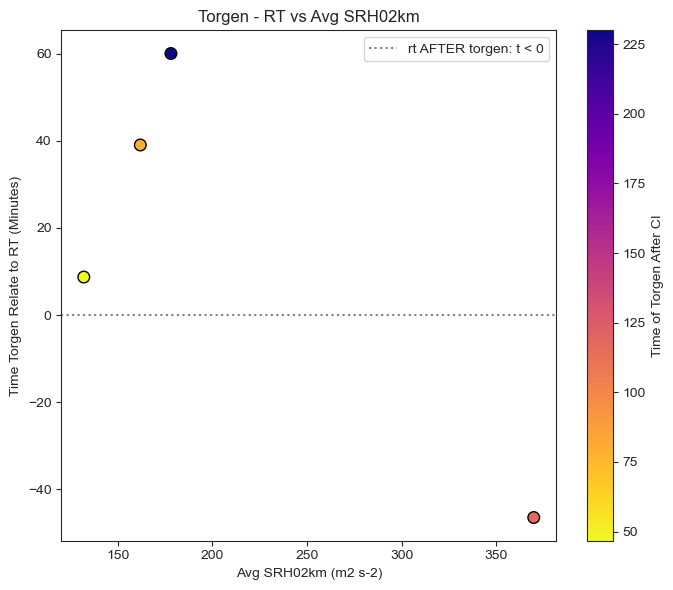

In [165]:
import matplotlib as mpl
fig = plt.figure(figsize=(7,6))

cmap = plt.cm.plasma_r
norm = mpl.colors.Normalize(
vmin=avg_srh_df['torgen - ci (min)'].min(),
vmax=avg_srh_df['torgen - ci (min)'].max()
    )
#sns.scatterplot(data=avg_srh_df, x=lab, y='torgen - rt (min)', hue='TNT', ax=axes, palette=['orange', 'tab:blue'])
scatter = plt.scatter(avg_srh_df['Avg SRH01km'], avg_srh_df['torgen - rt (min)'], c= avg_srh_df['torgen - ci (min)'], cmap=cmap, norm=norm, edgecolor='black', s=70)
cbar = fig.colorbar(scatter)
cbar.set_label('Time of Torgen After CI')
plt.ylabel('Time Torgen Relate to RT (Minutes)')
plt.xlabel(f'{lab} (m2 s-2)')
plt.title(f'Torgen - RT vs {lab}')
plt.axhline(0, linestyle=':', color='gray', label='rt AFTER torgen: t < 0')
plt.legend()

        
plt.tight_layout()

In [28]:
srh_cols = cases_df.filter(regex='^SRH')
srw_cols = cases_df.filter(regex='^SRW')

In [29]:
srh_cols['Date'] = cases_df['Date']
srw_cols['Date'] = cases_df['Date']

In [30]:
srh_cols['t_ci - t_rt'] = srh_cols['Date'].map(
    avg_srh_df.set_index('Date')['t_ci - t_rt']
)

srh_cols['TNT'] = srh_cols['Date'].map(
    avg_srh_df.set_index('Date')['TNT']
)

In [31]:
srh_cols['Date'].value_counts()

Date
20230615    924
20240501    850
20230527    506
20230611    388
20240427    314
20230524    284
20240602    262
20220523    140
20220524    100
20230613     20
Name: count, dtype: int64

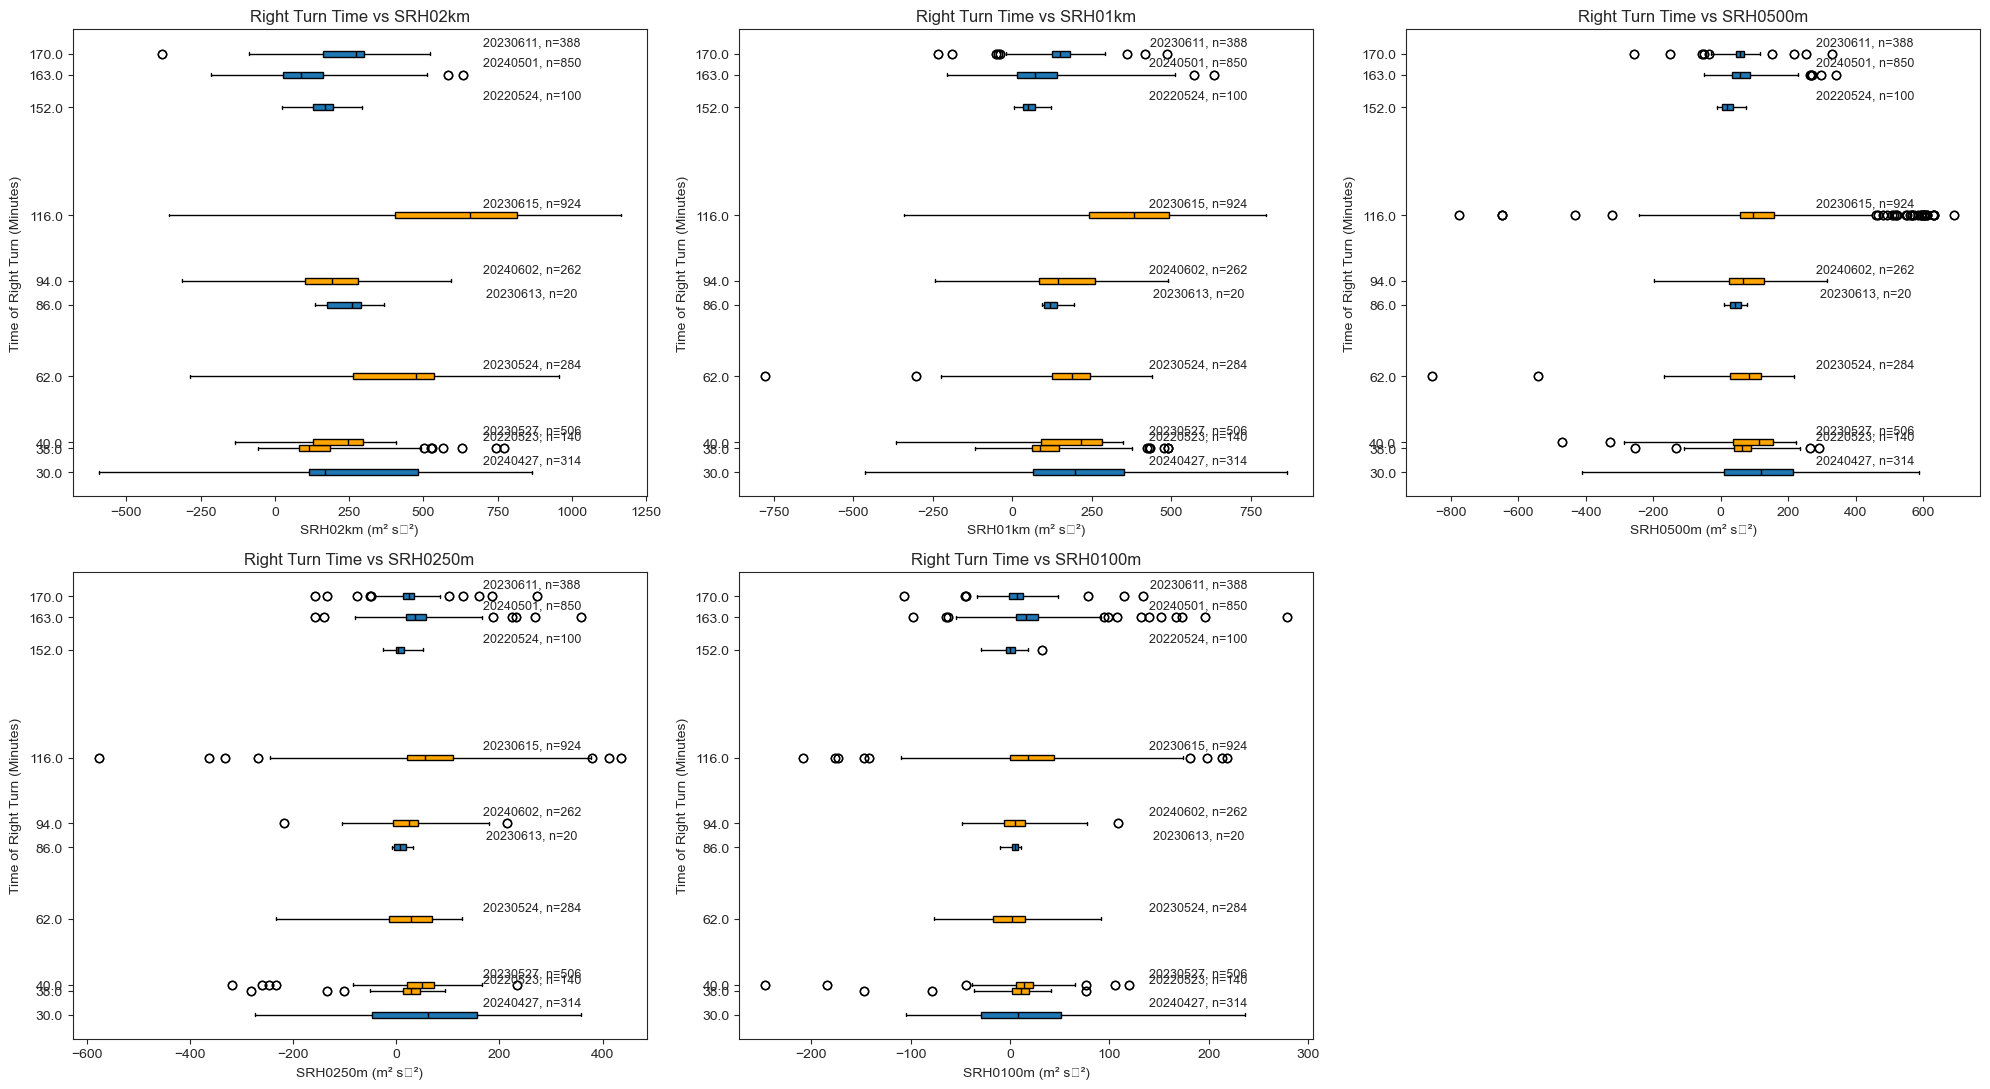

In [141]:
# SRH columns
labels = [col for col in srh_cols.columns
          if col not in ['Date', 'TNT', 't_ci - t_rt']]

dates = srh_cols['Date'].unique()

fig, ax = plt.subplots(2, 3, figsize=(20, 11))

for axes, lab in zip(ax.flat, labels):

    box_data = []
    positions = []
    colors = []
    box_dates = []

    for d in dates:

        df = srh_cols[srh_cols['Date'] == d]

        rt_time = df['t_ci - t_rt'].iloc[0]
        values = df[lab].dropna().values

        if len(values) == 0 or pd.isna(rt_time):
            continue

        box_data.append(values)
        positions.append(rt_time)
        box_dates.append(d)

        if df['TNT'].iloc[0] == 'tor':
            colors.append('orange')
        else:
            colors.append('tab:blue')

    median_props = dict(color='k')

    bp = axes.boxplot(
        box_data,
        positions=positions,
        vert=False,
        widths=2,
        patch_artist=True,
        medianprops=median_props,
        whis=3
    )

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)

    # Add date and n above each box
    for pos, d, values in zip(positions, box_dates, box_data):
        axes.text(
            0.8, pos + 2,
            f'{d}, n={len(values)}',
            transform=axes.get_yaxis_transform(),
            ha='center',
            va='bottom',
            fontsize=9
        )

    axes.set_xlabel(f'{lab} (m² s⁻²)')
    axes.set_ylabel('Time of Right Turn (Minutes)')
    axes.set_title(f'Right Turn Time vs {lab}')

# Hide unused subplots
for axes in ax.flat[len(labels):]:
    axes.set_visible(False)
    
plt.tight_layout()

In [34]:
first_srh_df = (
    srh_cols.groupby('Date')
    .first()
    .add_prefix('First ')
    .reset_index()
)

first_srw_df = (
    srw_cols.groupby('Date')
    .first()
    .add_prefix('First ')
    .reset_index()
)

max_srh_df = (
    srh_cols.groupby('Date')
    .max()
    .add_prefix('Max ')
    .reset_index()
)

max_srw_df = (
    srw_cols.groupby('Date')
    .first()
    .add_prefix('Max ')
    .reset_index()
)

In [35]:
first_srh_df 

,Date,First SRH02km,First SRH01km,First SRH0500m,First SRH0250m,First SRH0100m,First t_ci - t_rt,First TNT
0,20220523,119.748598,85.210929,43.718735,37.812320,17.004567,38.0,tor
1,20220524,91.169085,44.468119,18.790548,9.668138,0.315935,152.0,nontor
2,20230524,148.255528,-144.881089,-144.651774,-17.400846,-9.819850,62.0,tor
3,20230527,49.758976,-63.837406,120.948804,233.073760,65.530579,40.0,tor
4,20230611,406.946811,292.759757,218.010741,159.454746,114.126998,170.0,nontor
5,20230613,255.615399,131.738958,60.329751,19.301456,3.858587,86.0,nontor
6,20230615,-355.269524,219.326651,117.146618,33.968843,3.920068,116.0,tor
7,20240427,187.434504,202.249827,238.759530,187.938825,39.051630,30.0,nontor
8,20240501,34.604085,21.201866,10.957417,-6.601124,0.263519,163.0,nontor
9,20240602,201.670563,130.136127,47.644380,38.395185,50.621520,94.0,tor


In [36]:
srh_df = avg_srh_df.merge(first_srh_df, on='Date', how='left')
srh_df = srh_df.merge(max_srh_df, on='Date', how='left')

srw_df = avg_srw_df.merge(first_srw_df, on='Date', how='left')
srw_df = avg_srw_df.merge(max_srw_df, on='Date', how='left')

srhw_df = srh_df.merge(srw_df, on='Date', how='left')

In [37]:
srhw_df

,Date,Avg SRH0100m,Avg SRH0250m,Avg SRH0500m,Avg SRH01km,Avg SRH02km,t_ci - t_rt_x,TNT_x,First SRH02km,First SRH01km,...,Avg SRW0500m,Avg SRW01km,Avg SRW02km,t_ci - t_rt_y,TNT_y,Max SRW02km,Max SRW01km,Max SRW0500m,Max SRW0250m,Max SRW0100m
0,20220523,8.109902,22.726870,64.482854,132.018582,179.940742,38.0,tor,119.748598,85.210929,...,21.984190,19.508733,13.761503,38.0,tor,13.340017,18.473383,19.286532,19.810587,18.694960
1,20220524,0.968450,7.521204,20.541894,53.414833,160.195824,152.0,nontor,91.169085,44.468119,...,14.093218,12.460592,11.778441,152.0,nontor,7.263254,6.702574,8.866260,8.386769,8.647791
2,20230524,-2.839331,16.090263,53.913171,168.585174,420.468352,62.0,tor,148.255528,-144.881089,...,30.768141,29.674326,25.624495,62.0,tor,24.835802,12.271125,11.822184,12.415656,13.253067
3,20230527,13.013758,42.358086,88.468845,178.039582,214.579911,40.0,tor,49.758976,-63.837406,...,20.887613,19.144194,12.491597,40.0,tor,16.048932,19.408849,15.651947,14.547807,12.458110
4,20230611,6.049666,24.281898,55.378466,146.703049,230.764692,170.0,nontor,406.946811,292.759757,...,21.787713,18.649731,13.818256,170.0,nontor,16.943004,24.703433,24.659106,20.256466,19.671720
5,20230613,3.071447,8.456100,44.278354,129.454287,250.283200,86.0,nontor,255.615399,131.738958,...,12.038875,16.580487,18.884675,86.0,nontor,21.958672,18.916721,16.393803,15.800992,13.301029
6,20230615,23.563188,74.620566,128.994032,369.714944,607.931229,116.0,tor,-355.269524,219.326651,...,31.583985,28.684980,23.922742,116.0,tor,26.968317,31.093499,30.058018,29.073282,28.117477
7,20240427,18.613305,57.866353,111.049824,198.984654,260.880976,30.0,nontor,187.434504,202.249827,...,25.561435,21.669118,18.630775,30.0,nontor,7.017204,6.798789,16.706788,19.479517,20.649668
8,20240501,19.393454,39.968633,64.264519,86.010638,101.081522,163.0,nontor,34.604085,21.201866,...,19.218645,0.000000,0.000000,163.0,nontor,0.000000,0.000000,10.448333,11.039736,11.401415
9,20240602,5.610866,20.290107,72.049823,161.857395,198.917177,94.0,tor,201.670563,130.136127,...,18.106632,19.984964,2.443207,94.0,tor,0.000000,28.853253,25.048886,19.228515,15.478999


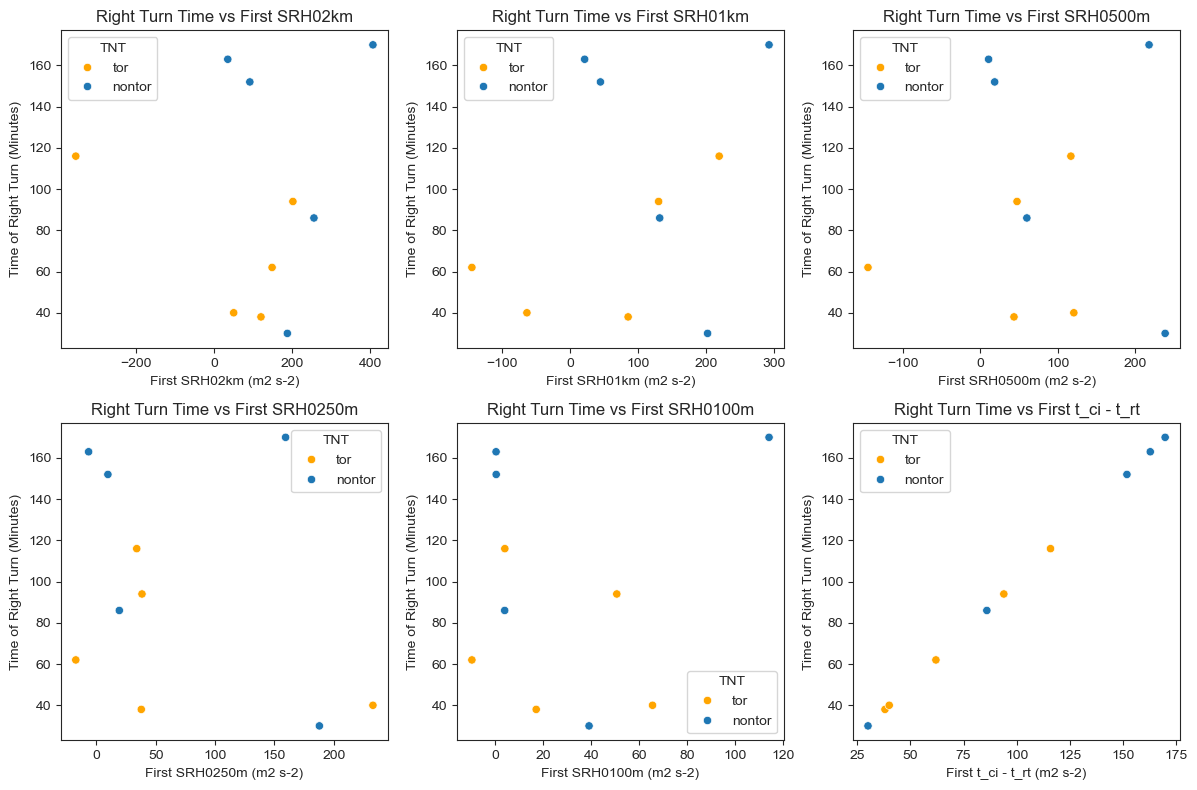

In [142]:
fig, ax = plt.subplots(2,3, figsize=(12,8))

labels = srh_df[[col for col in srh_df.columns if col.startswith('First')]]

for axes, lab in zip(ax.flat, labels):
    sns.scatterplot(data=srh_df, x=lab, y='t_ci - t_rt', hue='TNT', ax=axes, palette=['orange', 'tab:blue'])
    axes.set_ylabel('Time of Right Turn (Minutes)')
    axes.set_xlabel(f'{lab} (m2 s-2)')
    axes.set_title(f'Right Turn Time vs {lab}')
    
    for axes in ax.flat[len(labels):]:
        axes.set_visible(False)

plt.tight_layout()

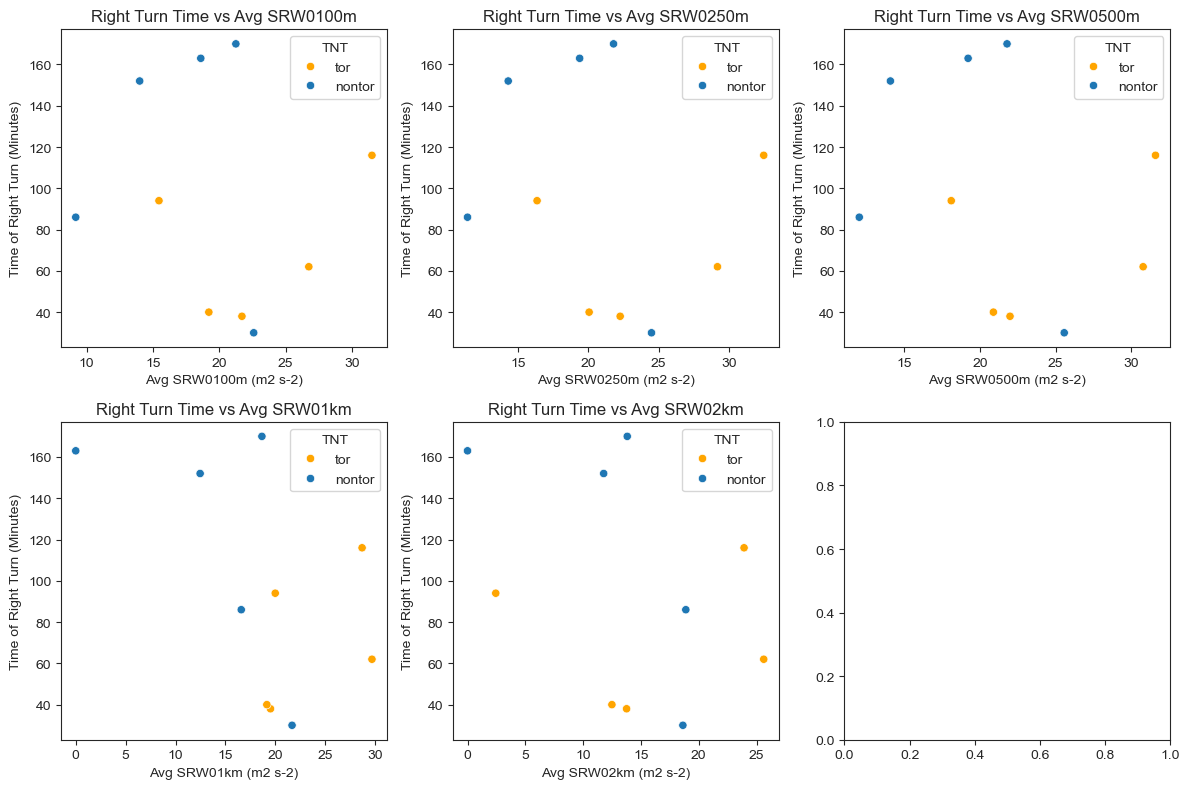

In [143]:
fig, ax = plt.subplots(2,3, figsize=(12,8))

labels = srw_df[[col for col in srw_df.columns if col.startswith('Avg')]]
for axes, lab in zip(ax.flat, labels):
    sns.scatterplot(data=srw_df, x=lab, y='t_ci - t_rt', hue='TNT', ax=axes, palette=['orange', 'tab:blue'])
    axes.set_ylabel('Time of Right Turn (Minutes)')
    axes.set_xlabel(f'{lab} (m2 s-2)')
    axes.set_title(f'Right Turn Time vs {lab}')
    
    for axes in ax.flat[len(labels):]:
        axes.set_visible(False)

plt.tight_layout()

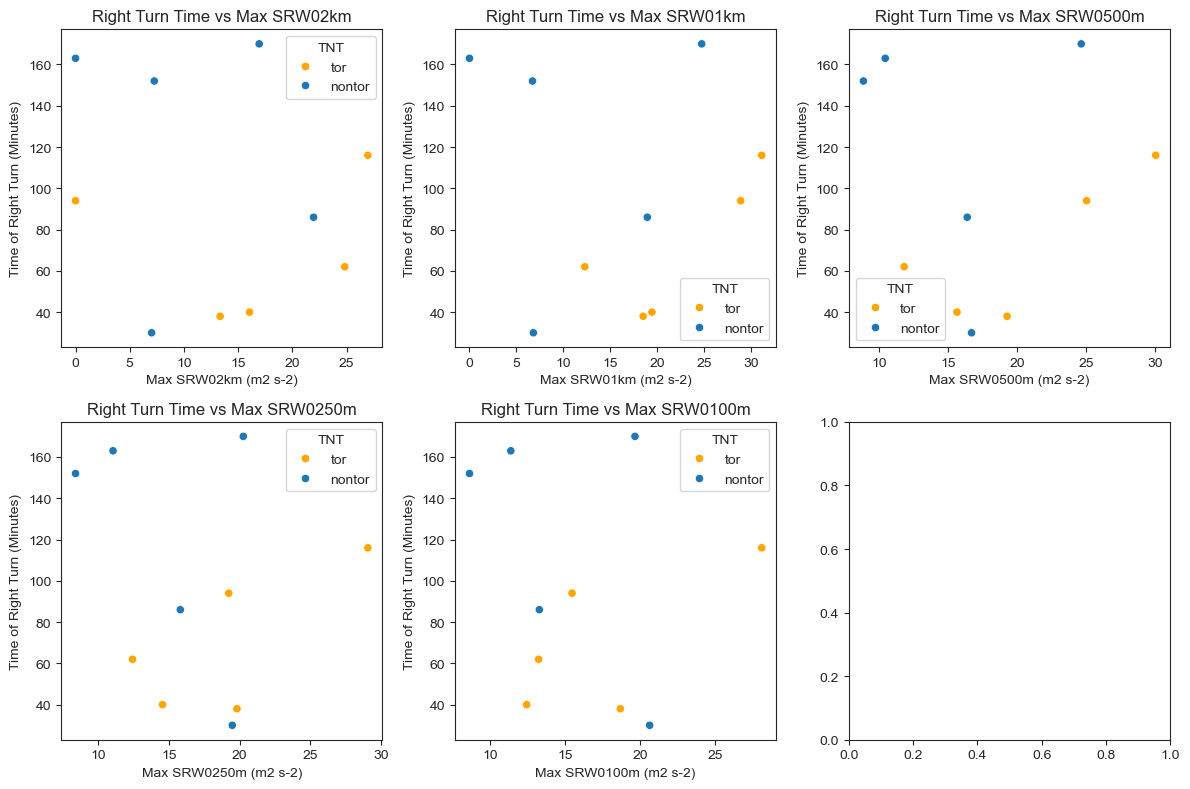

In [144]:
fig, ax = plt.subplots(2,3, figsize=(12,8))

labels = srw_df[[col for col in srw_df.columns if col.startswith('Max')]]
for axes, lab in zip(ax.flat, labels):
    sns.scatterplot(data=srw_df, x=lab, y='t_ci - t_rt', hue='TNT', ax=axes, palette=['orange', 'tab:blue'])
    axes.set_ylabel('Time of Right Turn (Minutes)')
    axes.set_xlabel(f'{lab} (m2 s-2)')
    axes.set_title(f'Right Turn Time vs {lab}')
    
    for axes in ax.flat[len(labels):]:
        axes.set_visible(False)

plt.tight_layout()